# Energy and Oil 

In [2]:
import pandas as pd
import re
import os
import json
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import gower
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import random


from dotenv import load_dotenv
import os

# Load the .env file from the current directory
load_dotenv()

gemini_key = os.getenv("GEMINI_KEY")

## Filter Energy and Oil Posts

In [3]:
# Load raw dataset with explicit handling
input_path = "../../trump_posts_full.csv"
if not os.path.exists(input_path):
    # Fallback check for local directory
    input_path = "trump_posts_full.csv"

df = pd.read_csv(input_path)
print(f"Loaded raw dataset with {len(df)} total rows.")

# ==============================================================================
# 0. TEMPORAL FILTER: ISOLATE SECOND TERM & TRANSITION PERIOD
# ==============================================================================
# Ensure timezone-naive comparison and robust datetime parsing
df['parsed_date'] = pd.to_datetime(df['created_at'], errors='coerce').dt.tz_localize(None)

# Start boundary: November 5, 2024 (Election Victory / Transition entry)
# End boundary: April 24, 2026 (Per your market data timeline)
start_date = pd.to_datetime('2024-11-05')
end_date = pd.to_datetime('2026-04-24')

df = df[(df['parsed_date'] >= start_date) & (df['parsed_date'] <= end_date)].copy()
print(f"Filtered to timeline ({start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}): {len(df)} posts remaining.")


# Comprehensive Oil and Energy Keyword Dictionary for Trump Post Filtering
# Stage 1: Construct the oil-post corpus
trump_oil_keywords = {
    "oil_petroleum": [
        "oil", "petroleum", "crude", "liquid gold", "black gold", "barrel", "barrels",
        "sanctioned oil", "oil reserves", "oil fields", "oil tankers", "oil prices"
    ],
    "drilling_infrastructure": [
        "drilling", "drill", "pipelines", "pipeline", "refineries", "refinery", "offshore drilling",
        "drill baby drill", "modernized drilling", "Alaska Pipeline", "permitting for energy", 
        "energy facilities", "infrastructure"
    ],
    "domestic_production": [
        "domestic production", "energy independence", "energy dominance", "American energy", "production",
        "America First Energy Dominance", "Unleash American Energy Dominance", "Restore American Energy Dominance", 
        "Expand oil production", "Gulf of America"
    ],
    "strategic_reserves": [
        "strategic petroleum reserve", "strategic reserves", "SPR", "refilling the reserve"
    ],
    "sanctions": [
        "sanctions", "secondary sanctions", "oil sanctions", "sanction relief", "blockade",
        "sanctioned oil tankers", "banking sanctions", "blockade of sanctioned oil"
    ],
    "opec": [
        "OPEC", "cartels", "price fixing", "petrodollar", "foreign producers"
    ],
    "geopolitical_supply_risk": [
        "geopolitical risk", "supply disruption", "Strait of Hormuz", "Middle East", "conflict",
        "Iran", "Venezuela", "Russia", "Saudi Arabia", "Maduro Regime", "Strait of Hormuz closure", "shipping lanes"
    ],
    "petrol_prices": [
        "gas prices", "gasoline prices", "fuel prices", "gas pump", "gasoline",
        "gasoline is cheap", "gasoline prices are plummeting", "energy costs", "petrol products"
    ],
    "anti_green_and_ev": [
        "green new scam", "EV mandate", "windmills", "solar", "electric vehicles",
        "green tax credits", "windmills are an economic and environmental disaster", 
        "repaying EV mandate", "expensive and inefficient energy", "forced electric car mandate"
    ]
}

def filter_oil_posts(df, text_column='text'):
    """
    Filters a pandas DataFrame of Truth Social posts based on the comprehensive keyword dictionary.
    Returns a filtered DataFrame containing posts that match any of the thematic keywords.
    """
    # Flatten all keywords into a single case-insensitive regex pattern
    all_keywords = [kw for category in trump_oil_keywords.values() for kw in category]
    pattern = '|'.join(r'\b' + re.escape(kw) + r'\b' for kw in all_keywords)
    
    # Apply filtering mask
    mask = df[text_column].str.contains(pattern, case=False, na=False, regex=True)
    filtered_df = df[mask].copy()
    
    print(f"Original dataset size: {len(df)}")
    print(f"Filtered oil/energy corpus size: {len(filtered_df)} ({len(filtered_df)/len(df)*100:.2f}%)")
    
    return filtered_df

oil_corpus_df = filter_oil_posts(df, text_column='text')
oil_corpus_df.to_csv("oil_posts.csv", index=False)

# Print diagnostic summary for academic reporting
total_posts = len(df)
extracted_posts = len(oil_corpus_df)
retention_rate = (extracted_posts / total_posts) * 100 if total_posts > 0 else 0

print(f"\n--- EXTRACTION SUMMARY ---")
print(f"Total posts in time window: {total_posts}")
print(f"Extracted High-Impact Oil posts: {extracted_posts} ({retention_rate:.2f}% yield)")
print(f"Saved filtered output to 'oil_posts.csv'. Ready for LLM scoring and Gower clustering.")

# Export clean dataset
oil_corpus_df.to_csv("oil_posts.csv", index=False)

/var/folders/7t/hbpvnt0x735gtn7m4hv4_01r0000gn/T/ipykernel_49601/184657180.py:7: DtypeWarning: Columns (0: is_policy_related) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


Loaded raw dataset with 32754 total rows.
Filtered to timeline (2024-11-05 to 2026-04-24): 9019 posts remaining.
Original dataset size: 9019
Filtered oil/energy corpus size: 1106 (12.26%)

--- EXTRACTION SUMMARY ---
Total posts in time window: 9019
Extracted High-Impact Oil posts: 1106 (12.26% yield)
Saved filtered output to 'oil_posts.csv'. Ready for LLM scoring and Gower clustering.


### Filtering Noisy Posts

In [30]:
# 1. Load your candidate posts (e.g., the 1,106 filtered posts)
df_posts = pd.read_csv("oil_posts.csv")


def rigorous_two_stage_filter(text):
    if not isinstance(text, str):
        return 0, "Invalid text"
    text_lower = text.lower()

    # 1. STRONG PHYSICAL ENERGY ANCHORS (Core Petroleum & Infrastructure Terms)
    strong_anchors = [
        "oil", "petroleum", "crude", "liquid gold", "black gold", "barrel", "barrels",
        "sanctioned oil", "oil reserves", "oil fields", "oil tankers", "oil prices",
        "drilling", "drill", "pipelines", "pipeline", "refineries", "refinery", "offshore drilling",
        "drill baby drill", "modernized drilling", "alaska pipeline", "permitting for energy",
        "energy facilities", "infrastructure", "strategic petroleum reserve", "strategic reserves",
        "spr", "refilling the reserve", "gas prices", "gasoline prices", "fuel prices", "gas pump",
        "gasoline", "gasoline is cheap", "gasoline prices are plummeting", "energy costs", "petrol products",
        "energy dominance", "energy independence", "american energy", "production",
        "america first energy dominance", "unleash american energy dominance", "restore american energy dominance",
        "expand oil production", "gulf of america", "lng"
    ]

    # 3. ELECTORAL & CAMPAIGN NOISE BLACKLIST
    electoral_blacklist = [
        "endorse", "endorsed", "endorsement", "ballot", "vote", "voters",
        "election", "rally", "nominee", "candidate", "party", "campaign",
        "congress", "senate", "house of representatives", "fake news", "witch hunt", "elect"
    ]

    # Check matches using word boundaries
    has_strong_anchor = any(
        re.search(r'\b' + re.escape(a) + r'\b', text_lower) for a in strong_anchors)
    has_blacklist = any(re.search(r'\b' + re.escape(bl) +
                        r'\b', text_lower) for bl in electoral_blacklist)

    # RULE 1: Electoral Noise Override Check
    if has_blacklist:
        if has_strong_anchor and any(term in text_lower for term in ["drill", "production", "prices", "energy policy", "reserve", "tariffs", "gasoline"]):
            return 1, "Passed: Political post with explicit energy policy anchor"
        else:
            return 0, "Filtered: Electoral/Campaign noise (False Positive)"

    # RULE 2 & 3: True Co-Occurrence Logic
    if has_strong_anchor:
        return 1, "Passed: Explicit physical energy anchor"

    # RULE 4: Default Rejection
    return 0, "Filtered: Insufficient energy context or general political noise"


# Apply rule to dataset
df_posts['Relevance_Flag'], df_posts['Relevance_Reason'] = zip(
    *df_posts['text'].map(rigorous_two_stage_filter))

# 2. Split into filtered corpus and excluded sample for precision/recall audit
oil_posts_v3 = df_posts[df_posts['Relevance_Flag'] == 1].copy()
excluded_posts = df_posts[df_posts['Relevance_Flag'] == 0].copy()

# 3. Drop exact or near-duplicates
oil_posts_v3 = oil_posts_v3.drop_duplicates(
    subset=['text']).reset_index(drop=True)
oil_posts_v3.to_csv("oil_posts_v3.csv", index=False)


# with pd.ExcelWriter('oil_posts_v3.xlsx') as writer:
#     oil_posts_v3.to_excel(writer, sheet_name='Kept', index=False)


def contains_link(text):
    if not isinstance(text, str):
        return False
    cleaned = text.strip()

    # Regex pattern matching a URL appearing anywhere in the text
    url_pattern = r'(https?://|www\.)\S+'

    return bool(re.search(url_pattern, cleaned))


contains_link_mask = oil_posts_v3['text'].apply(contains_link)  # one bool per row
contains_link_count = contains_link_mask.sum()  # counts posts, not links


print("Two-stage relevance filter logic defined successfully.")
print(f"Filtered posts size: {len(oil_posts_v3)}")
print(f"Excluded posts size: {len(excluded_posts)}")
print(
    f"Duplicated posts: {len(oil_corpus_df) - (len(excluded_posts) + len(oil_posts_v3))}")
print(f"Number of posts that are just links: {contains_link_count}")

Two-stage relevance filter logic defined successfully.
Filtered posts size: 198
Excluded posts size: 900
Duplicated posts: 8
Number of posts that are just links: 35


## Set up posts into JSON for scoring

In [38]:
import json
import re
import pandas as pd


# 1. Load the 942 filtered oil posts dataset
df = pd.read_csv('oil_posts_v3.csv')

# 1b. Load the rubric so blank score slots always match the current feature
# set (v1.2: 8 OIL_MARKET/OIL_AFFE/OIL_PRAG features, keyed by id)
with open('oil_rubric_v1_2.json', 'r', encoding='utf-8') as f:
    rubric_data = json.load(f)
FEATURE_IDS = [feature["id"] for feature in rubric_data]

# 1c. Load the URL archive (v2 schema: "links" array per record, supports
# multi-link posts) and index by record_id
with open('url_archive.json', 'r', encoding='utf-8') as f:
    archive_data = json.load(f)
archive_by_id = {r['record_id']: r for r in archive_data}

# Pattern to detect a post that is nothing but a bare URL (no independent
# caption) - used to flag records where rhetorical features (affect,
# sarcasm) have no text to be scored from, per the manual's rule that
# these two features must be scored from Trump's own words only.
URL_ONLY_PATTERN = re.compile(r'^\s*(https?://\S+)\s*$')

json_records = []

# 2. Iterate through rows and build post-comment schema
for idx, row in df.iterrows():
    post_text = str(row['text']).strip() if pd.notnull(row.get('text')) else ""
    if not post_text or post_text.lower() == 'nan':
        continue

    post_id = str(row['id']) if pd.notnull(row.get('id')) else str(idx)
    created_utc = str(row['created_at']) if pd.notnull(row.get('created_at')) else None
    like_count = int(row['like_count']) if pd.notnull(row.get('like_count')) else 0
    retruth_count = int(row['retruth_count']) if pd.notnull(row.get('retruth_count')) else 0
    reply_count = int(row['reply_count']) if pd.notnull(row.get('reply_count')) else 0
    url = str(row['url']) if pd.notnull(row.get('url')) else None
    topic = str(row['topic']) if pd.notnull(row.get('topic')) else None
    countries_mentioned = str(row['countries_mentioned']) if pd.notnull(row.get('countries_mentioned')) else None


    archive_entry = archive_by_id.get(post_id)
    resolution = None
    if archive_entry:
        resolution = {
            "links": archive_entry.get("links", []),
        }

    # 2c. Flag posts that are nothing but a bare URL - these have no
    # independent rhetorical signal, so OIL_AFFE_01/OIL_PRAG_01 should be
    # scored 0 (confirmed absent), not 9 (ambiguous), during scoring.
    text_is_url_only = bool(URL_ONLY_PATTERN.match(post_text))

    # 2d. Blank eligibility gate + scoring structure. Decided BEFORE feature
    # scoring, per the manual - included here (rather than left implicit)
    # so this file works as a template for either the LLM scorer or a human
    # reviewer, and so every downstream consumer sees the same shape.
    eligibility = {
        "corpus_eligibility": None,     # one of ELIGIBILITY_CODES
        "exclusion_reason": None,       # set only if corpus_eligibility == EXCLUDE
        "energy_evidence_span": None,   # shortest phrase justifying INCLUDE_*
    }

    # Feature scores default to None (not 0) - 0 means "confirmed absent",
    # None means "not yet scored" or "not applicable" (excluded/unresolved
    # record). Nested per feature to match the LLM output schema exactly,
    # so this file and the scored output file share one shape throughout
    # the pipeline. The one exception coders/models apply at scoring time,
    # not here: a url-only post's OIL_AFFE_01/OIL_PRAG_01 should be set to
    # 0 once eligibility is decided, since absence of rhetoric is certain.
    scores = {
        feature_id: {"score": None, "evidence_span": None, "justification": None}
        for feature_id in FEATURE_IDS
    }

    # Construct object matching IAFOR schema including the 'comment' key
    record = {
        "comment": post_text,  # Main target text evaluated by LLM scorer
        "comment_metadata": {
            "id": post_id,
            "created_utc": created_utc,
            "url": url,
            "like_count": like_count,
            "retruth_count": retruth_count,
            "reply_count": reply_count,
            "topic": topic,
            "countries_mentioned": countries_mentioned,
            "source": "truth_social"
        },
        "resolution": resolution,               # None if not URL-resolved
        "text_is_url_only": text_is_url_only,    # True if "comment" has no caption
        "eligibility": eligibility,
        "scores": scores,
    }
    json_records.append(record)

# 2e. Sanity check: flag archive entries that never matched a post in the
# filtered corpus - could mean an id-format mismatch (e.g. string vs int),
# or a post that got filtered out of v3 despite being archived, worth
# checking rather than silently losing the archived resolution.
matched_ids = {r["comment_metadata"]["id"] for r in json_records}
unmatched_archive_ids = [rid for rid in archive_by_id if rid not in matched_ids]
if unmatched_archive_ids:
    print(f"Warning: {len(unmatched_archive_ids)} archived record_ids had no "
          f"matching post in oil_posts_v3.csv: {unmatched_archive_ids[:10]}"
          f"{'...' if len(unmatched_archive_ids) > 10 else ''}")

resolved_count = sum(1 for r in json_records if r["resolution"] is not None)
multi_link_count = sum(
    1 for r in json_records
    if r["resolution"] and len(r["resolution"]["links"]) > 1
)
print(f"Attached archive resolution to {resolved_count} of {len(json_records)} posts "
      f"({multi_link_count} with more than one link).")

# 3. Export to JSON
output_json_path = "oil_posts_v3.json"
with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(json_records, f, indent=2, ensure_ascii=False)

print(f"Exported {len(json_records)} items to '{output_json_path}'.")

Attached archive resolution to 35 of 198 posts (1 with more than one link).
Exported 198 items to 'oil_posts_v3.json'.


## Manual Scoring

In [44]:
import json
import random


def get_random_scoring_sample(input_json_path, output_json_path, sample_size=50, random_seed=42):
    # Load the posts data
    with open(input_json_path, 'r', encoding='utf-8') as f:
        posts_data = json.load(f)

    # Set seed for reproducibility across runs
    if random_seed is not None:
        random.seed(random_seed)

    # Sample randomly if the total dataset is larger than the requested size
    actual_size = min(sample_size, len(posts_data))
    sampled_posts = random.sample(posts_data, actual_size)

    # Save the updated data structure to a new file
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(sampled_posts, f, indent=2, ensure_ascii=False)

    print(f"Successfully generated random human-validation template with {actual_size} posts, saved to: {output_json_path}")


# Example usage (assuming your source file is named 'oil_posts_v2.json'):
get_random_scoring_sample('oil_posts_v3.json', 'oil_posts_v3_to_score.json')

Successfully generated random human-validation template with 50 posts, saved to: oil_posts_v3_to_score.json


## Score the posts in batches

In [10]:
import json
import time
from google import genai
from google.genai import types

# 1. Initialize Gemini Client
client = genai.Client(api_key=gemini_key)

# Choose target model
MODEL_NAME = "gemini-3.5-flash-lite"
# NOTE: double check this string against the current model list before a
# full run - if it doesn't match an existing model exactly, every call will
# fail and you'll burn retries silently.

# 2. Load the input posts dataset
with open('oil_posts_v3.json', 'r', encoding='utf-8') as f:
    posts_data = json.load(f)


with open('oil_rubric_v1_4.json', 'r', encoding='utf-8') as f:
    rubric_data = json.load(f)

FEATURE_IDS = [f["id"] for f in rubric_data["features"]]
ELIGIBILITY_CODES = [c["code"] for c in rubric_data["eligibility"]["codes"]]
EXCLUSION_REASON_CODES = [c["code"]
                          for c in rubric_data["eligibility"]["exclusion_reasons"]]

rubric_block = "\n\n".join(
    f"### {f['id']} — {f['feature']}\n{f['rubric']}"
    for f in rubric_data["features"]
)

eligibility_block = "\n".join(
    f"- {c['code']}: {c['description']}"
    for c in rubric_data["eligibility"]["codes"]
)

exclusion_reason_block = "\n".join(
    f"- {c['code']}: {c['description']}"
    for c in rubric_data["eligibility"]["exclusion_reasons"]
)

scores_template = ",\n".join(
    f'''        "{fid}": {{
          "score": <int, or null if not applicable>,
          "evidence_span": "<shortest supporting quote or null>",
          "justification": "<1-2 sentences tied to explicit wording, or null>"
        }}'''
    for fid in FEATURE_IDS
)

SYSTEM_PROMPT = f"""You are a literal-minded coder scoring Trump Truth Social posts for an
oil/energy-market study, benchmarked against an adjudicated human standard.
Apply the rubric provided below exactly - do not use your own judgement about intent.

RULES:
- Code only the visible text. No hindsight (don't infer later market moves),
  no engagement signals, no assumptions about what Trump "generally" means.
- A keyword is not evidence ("barrels" of meth, "production" of cars/chips,
  generic "made in America" are not oil content unless context confirms it).
- Score each feature independently - e.g. pro-drilling does not imply
  anti-green or energy-nationalism without its own separate evidence, and
  a severe geopolitical threat (OIL_MARKET_02) does not by itself dictate
  OIL_DIRECTION_01 - price direction depends on the specific mechanism, not
  the threat's severity.
- Judge affect/blame/nationalism from the energy-relevant passage only, not
  unrelated capitalisation or insults elsewhere in a long post.
- null vs 0 vs 9: 0 = confirmed absent (or, for OIL_DIRECTION_01, no clear
  price implication). null = not applicable (post excluded/unresolved).
  9 = eligible post but this feature is genuinely ambiguous. Never use 0
  for uncertainty - use 9 instead, and never guess.
- Each feature's rubric entry below lists its own "scores" array - that is
  the complete set of legal values for that feature and nothing else. A
  score must come from that exact feature's own array: never reuse a value
  from a different feature's array, never output a value the array doesn't
  contain (e.g. a 2 for a feature whose array stops at 1), and never invent
  a value not listed anywhere (e.g. 3, -2, 99). If uncertain which value
  applies, use that feature's own ambiguity code (9) rather than guessing
  or borrowing the nearest value from another feature.
- A post and its re-truth (identical text) must get identical scores.
- Rate your own confidence in this post's overall coding: 1 (low), 2
  (medium), or 3 (high). Use 1 when eligibility or multiple features were
  genuinely hard calls, not just when a score happens to be 9.

STEP 1 - ELIGIBILITY (decide before scoring anything else):
Assign exactly one code:
{eligibility_block}

If EXCLUDE, also choose exactly one exclusion_reason:
{exclusion_reason_block}

Record energy_evidence_span (shortest phrase justifying inclusion; null if
EXCLUDE/UNRESOLVED). If EXCLUDE or UNRESOLVED: set every feature score
(including OIL_DIRECTION_01) to null and stop.

STEP 2 - FEATURE SCORING (only if INCLUDE_CORE/INCLUDE_CONTEXT):
Score every feature in the rubric provided, including OIL_DIRECTION_01
(implied oil-price direction - a distinct question from topic/severity,
scored the same way as every other feature). For any non-zero score, give
an evidence_span (shortest exact quote) and a 1-2 sentence justification;
for OIL_DIRECTION_01 specifically, name the mechanism in that justification
rather than just asserting a direction. Do not claim causal certainty for
OIL_DIRECTION_01 - you are coding implied direction, not forecasting the
market. Use only the "scores" values listed for that specific feature id
in the rubric.

RESOLVED LINK CONTENT:
A post may include "links" (headline/subheading/article_excerpt per URL).
Use it for eligibility and every feature except OIL_AFFE_01/OIL_PRAG_01,
which score Trump's own rhetoric from "text" alone. Multiple links: eligible
if ANY link is oil/energy-relevant; cite the specific link's headline in
evidence_span. If "text" is empty or URL-only, score OIL_AFFE_01/OIL_PRAG_01
as 0 (confirmed absent), not 9.

OUTPUT FORMAT:
Return a valid JSON object matching this exact structure for the batch.
Every feature id in the rubric MUST appear as its own key inside "scores" -
do not omit any, and do not collapse them into fewer keys. Each "score"
value must be null, or exactly one of that feature's own "scores" values
from the rubric - never a value from a different feature's array and never
a value not listed for that feature at all:

{{
  "results": [
    {{
      "post_id": "string_matching_input_id",
      "corpus_eligibility": "<one of {ELIGIBILITY_CODES}>",
      "exclusion_reason": "<one of {EXCLUSION_REASON_CODES} or null>",
      "energy_evidence_span": "<shortest supporting phrase or null>",
      "scores": {{
{scores_template}
      }},
    }}
  ]
}}

Every field must be present even when null. Use exactly the feature ids
from the rubric as "scores" keys - do not invent, rename, or omit any.
Output only the JSON object - no preamble, no ```json fences.
"""


def score_batch(batch_payload, retries=3):
    """Sends micro-batch of posts to Gemini API with backoff retry logic."""
    prompt_content = f"Evaluate these {len(batch_payload)} posts:\n" + json.dumps(batch_payload, indent=2)

    for attempt in range(retries):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt_content,
                config=types.GenerateContentConfig(
                    system_instruction=SYSTEM_PROMPT,
                    response_mime_type="application/json",
                    temperature=0.0
                )
            )
            return json.loads(response.text)
        except Exception as e:
            print(f"Error on attempt {attempt + 1}: {e}")
            time.sleep(2 ** attempt)

    return None


for j in range(3):
    # 3. Process in Chunks
    BATCH_SIZE = 5
    final_formatted_output = []
    total_posts = len(posts_data)

    print(f"Starting batch evaluation for {total_posts} posts... Run {j+1}")

    for i in range(0, total_posts, BATCH_SIZE):
        batch = posts_data[i: i + BATCH_SIZE]

        # Create lightweight prompt payload - include links only when present,
        # to keep the payload small for the ~830 posts with no URL to resolve
        batch_payload = [
            {
                "post_id": item["comment_metadata"]["id"],
                "text": item["comment"],
                **({"links": item["resolution"]["links"]}
                  if item.get("resolution") and item["resolution"].get("links")
                  else {})
            }
            for item in batch
        ]

        print(f"Run {j+1} || Evaluating posts {i + 1} to {min(i + BATCH_SIZE, total_posts)} / {total_posts}...")
        api_response = score_batch(batch_payload)

        # Map API results back to full output schema, keyed by post_id
        if api_response and "results" in api_response:
            results_lookup = {res["post_id"]: res for res in api_response["results"]}

            for item in batch:
                p_id = item["comment_metadata"]["id"]
                result = results_lookup.get(p_id, {})

                # Warn (rather than silently defaulting) when a model omits a
                # feature or returns something outside the allowed range - this
                # is exactly the kind of silent failure that produced the
                # zero-as-uncertainty problem in the original pilot.
                scores = result.get("scores", {})
                missing_features = [fid for fid in FEATURE_IDS if fid not in scores]
                if missing_features:
                    print(f"  Warning: post {p_id} missing scores for {missing_features}")

                formatted_record = {
                    "comment": item.get("comment", ""),
                    "resolution": item.get("resolution"),             # carried from input, not overwritten
                    "text_is_url_only": item.get("text_is_url_only"), # carried from input, not overwritten
                    "eligibility": {
                        "corpus_eligibility": result.get("corpus_eligibility"),
                        "exclusion_reason": result.get("exclusion_reason"),
                        "energy_evidence_span": result.get("energy_evidence_span"),
                    },
                    "scores": scores,
                    "confidence": result.get("confidence"),
                    "backend": "gemini",
                    "model": MODEL_NAME,
                    "comment_metadata": item.get("comment_metadata", {})
                }
                final_formatted_output.append(formatted_record)
        else:
            print(f"Run {j+1} Warning: Batch starting at index {i} failed evaluation.")

    # 4. Save formatted JSON dataset
    output_filename = f"oil_posts_v3_scored_LLM_gemini_run{j+1}_v4.json"
    with open(output_filename, 'w', encoding='utf-8') as f:
        json.dump(final_formatted_output, f, indent=2, ensure_ascii=False)

    print(f"\nProcessing Complete! Saved {len(final_formatted_output)} formatted items to '{output_filename}'.")

Starting batch evaluation for 198 posts... Run 1
Run 1 || Evaluating posts 1 to 5 / 198...
Run 1 || Evaluating posts 6 to 10 / 198...
Run 1 || Evaluating posts 11 to 15 / 198...
Run 1 || Evaluating posts 16 to 20 / 198...
Run 1 || Evaluating posts 21 to 25 / 198...
Run 1 || Evaluating posts 26 to 30 / 198...
Run 1 || Evaluating posts 31 to 35 / 198...
Run 1 || Evaluating posts 36 to 40 / 198...
Run 1 || Evaluating posts 41 to 45 / 198...
Run 1 || Evaluating posts 46 to 50 / 198...
Run 1 || Evaluating posts 51 to 55 / 198...
Run 1 || Evaluating posts 56 to 60 / 198...
Run 1 || Evaluating posts 61 to 65 / 198...
Run 1 || Evaluating posts 66 to 70 / 198...
Run 1 || Evaluating posts 71 to 75 / 198...
Run 1 || Evaluating posts 76 to 80 / 198...
Run 1 || Evaluating posts 81 to 85 / 198...
Run 1 || Evaluating posts 86 to 90 / 198...
Run 1 || Evaluating posts 91 to 95 / 198...
Run 1 || Evaluating posts 96 to 100 / 198...
Run 1 || Evaluating posts 101 to 105 / 198...
Run 1 || Evaluating posts 1

## Determine optimal k clusters

In [8]:
# 1. Load your scored dataset
with open("scored_oil_posts.json", "r", encoding="utf-8") as f:
    scored_data = json.load(f)

# 2. Flatten the nested structure
rows_for_df = []
for item in scored_data:
    record = {}
    record["post_id"] = item.get("comment_metadata", {}).get("id")
    record["text"] = item.get("comment")
    
    scores = item.get("scores", {})
    for key, val in scores.items():
        record[key] = val
        
    rows_for_df.append(record)

df_scored = pd.DataFrame(rows_for_df)

# 3. Define your feature columns
feature_columns = [
        "domestic_oil_gas_production_push",
        "geopolitical_chokepoint_supply_threat",
        "retail_gasoline_price_consumer_pain_framing",
        "macro_market_volatility_speculation_impact",
        "strategic_petroleum_reserve_spr_policy",
        "anti_green_renewable_mandate_pushback",
        "domestic_partisan_blame_institutional_scapegoating",
        "anti_cartel_energy_nationalism_framing",
        "rhetorical_urgency_affect",
        "sarcasm_irony"
]

# 4. CRITICAL FIX: Convert all feature columns explicitly to floats
X_features = df_scored[feature_columns].astype(float)

# 5. Compute the Gower Distance Matrix safely
gower_dist_matrix = gower.gower_matrix(X_features)

print(f"\nSuccess! Gower distance matrix computed.")
print(f"Matrix shape: {gower_dist_matrix.shape}")
print(gower_dist_matrix.min())
print(gower_dist_matrix.max())
print(gower_dist_matrix.mean())
print(gower_dist_matrix.std())
print(gower_dist_matrix[:5, :5])

FileNotFoundError: [Errno 2] No such file or directory: 'scored_oil_posts.json'

In [39]:
import numpy as np
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

for k in range(2, 8):

    model = KMedoids(
        n_clusters=k,
        metric="precomputed",
        init="k-medoids++",
        random_state=42,
    )

    labels = model.fit_predict(gower_dist_matrix)

    sil = silhouette_score(
        gower_dist_matrix,
        labels,
        metric="precomputed"
    )

    print(f"\nk={k}")
    print("Silhouette:", sil)
    print("Cluster sizes:", np.bincount(labels))
    print("Unique labels:", np.unique(labels))
    print("Medoids:", model.medoid_indices_)


k=2
Silhouette: 0.5113475322723389
Cluster sizes: [829 277]
Unique labels: [0 1]
Medoids: [860 105]

k=3
Silhouette: 0.5267513394355774
Cluster sizes: [610 277 219]
Unique labels: [0 1 2]
Medoids: [860 105   9]

k=4
Silhouette: 0.6008920073509216
Cluster sizes: [493 277 175 161]
Unique labels: [0 1 2 3]
Medoids: [860 105   9 661]

k=5
Silhouette: 0.6085052490234375
Cluster sizes: [478 273  39 155 161]
Unique labels: [0 1 2 3 4]
Medoids: [ 860  105  328  661 1044]

k=6
Silhouette: 0.6211889982223511
Cluster sizes: [478 255  39 155 161  18]
Unique labels: [0 1 2 3 4 5]
Medoids: [ 860  105  328  661 1044    1]

k=7
Silhouette: 0.6236763596534729
Cluster sizes: [482 258  21 154 157  18  16]
Unique labels: [0 1 2 3 4 5 6]
Medoids: [ 860  105   79  661 1044    1  424]


/Users/nitesh/Library/Mobile Documents/com~apple~CloudDocs/Documents/Masters Diss/Trump_Posts/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/nitesh/Library/Mobile Documents/com~apple~CloudDocs/Documents/Masters Diss/Trump_Posts/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
/Users/nitesh/Library/Mobile Documents/com~apple~CloudDocs/Documents/Masters Diss/Trump_Posts/myenv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:

## Plot UMAP of clustering

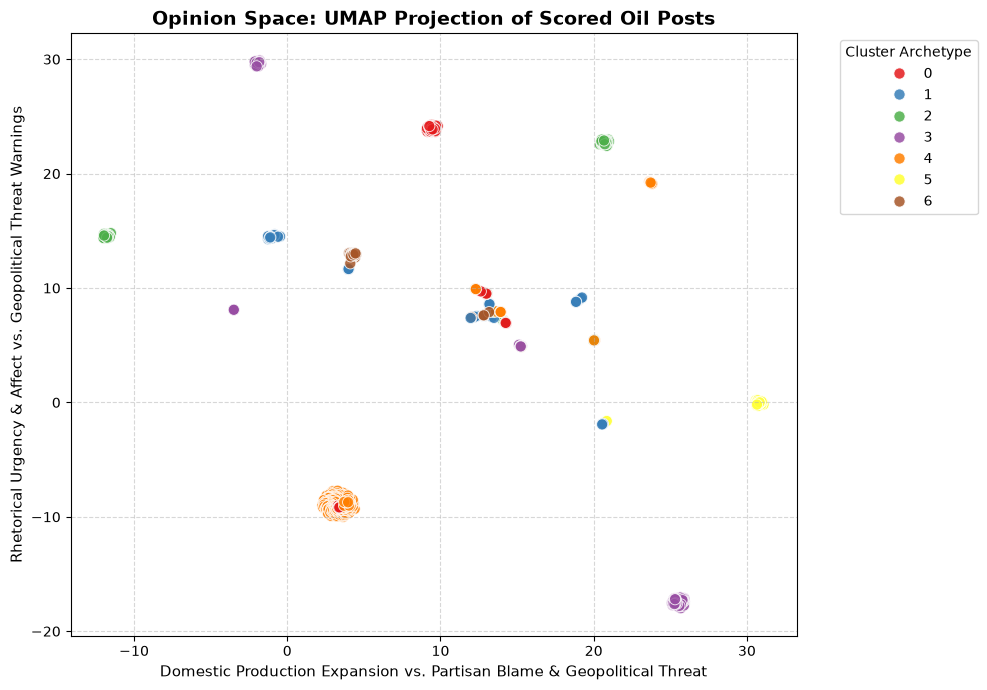

In [5]:
# 1. Load the JSON file (containing precomputed umap_x, umap_y, cluster_id, and scores)
with open("clustered_oil_posts.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# 2. Parse records into a Pandas DataFrame
records = []
for item in data:
    rec = {
        "post": item.get("post"),
        "umap_x": item.get("umap_x"),
        "umap_y": item.get("umap_y"),
        "cluster_id": item.get("cluster_id"),
        "post_id": item.get("post_metadata", {}).get("id"),
        "topic": item.get("post_metadata", {}).get("topic"),
    }
    # Unpack rubric score features for axis correlation analysis
    scores = item.get("scores", {})
    for k, v in scores.items():
        rec[k] = v

    records.append(rec)

df = pd.DataFrame(records)

# 3. Plot the 2D Opinion Space using Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x="umap_x",
    y="umap_y",
    hue="cluster_id",
    palette="Set1",
    s=65,
    alpha=0.85,
)

# 4. Add clear labels and title
plt.title(
    "Opinion Space: UMAP Projection of Scored Oil Posts",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel(
    "Domestic Production Expansion vs. Partisan Blame & Geopolitical Threat", fontsize=11
)
plt.ylabel(
    "Rhetorical Urgency & Affect vs. Geopolitical Threat Warnings", fontsize=11
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    title="Cluster Archetype", bbox_to_anchor=(1.05, 1), loc="upper left"
)

plt.tight_layout()
plt.savefig("Figures/umap_opinion_space_plot.pdf")
plt.show()

| UMAP Axis | Dimensional Orientation | Semantic Interpretation & Behavioral Gradient |
| :---: | :--- | :--- |
| **UMAP Dimension X** | **Domestic Economic & Administrative vs. International Geopolitical Engagement** | Separates domestic political endorsements, cabinet appointments, and routine administrative posts (positive spectrum) from high-stakes geopolitical conflicts, foreign security operations, and direct adversarial standoffs (negative spectrum). |
| **UMAP Dimension Y** | **Rhetorical Intensity / Hardline Confrontation vs. Institutional/Diplomatic Routine** | Distinguishes routine announcements, official rollouts, and standard political messaging (negative spectrum) from high-urgency rhetorical escalation, military threats, ultimatums, and crisis management language (positive spectrum). |

| Cluster ID | Archetypal Label | Coverage (%) | Thematic Focus & Discursive Style | Representative Post Themes |
| :---: | :--- | :---: | :--- | :--- |
| **0** | **Geopolitical Confrontation & Naval Security Enforcement** | 14.2% | Hardline military warnings, naval blockades, anti-cartel/narcoterrorism operations, and direct ultimatums to hostile regimes (e.g., Iran, Venezuela). | *"The United States to Blockade Ships Entering or Exiting Iranian Ports..."*, *"TOTAL AND COMPLETE BLOCKADE OF ALL SANCTIONED OIL TANKERS..."* |
| **1** | **Domestic Partisan Blame & Institutional Critique** | 18.5% | Direct attacks on political opponents, mainstream media institutions, past administrations (Biden/Obama), and systemic "lawfare" grievances. | *"Biden is doing everything possible to make the TRANSITION as difficult as possible..."*, *"The Democrats are really out of control..."* |
| **2** | **International Diplomacy & Peace-Through-Strength Accords** | 11.8% | Announcements of ceasefires, hostage releases, peace negotiations (Middle East, Russia-Ukraine), and international coalition building. | *"WE HAVE A DEAL FOR THE HOSTAGES IN THE MIDDLE EAST..."*, *"GREAT TALKS WITH RUSSIA AND UKRAINE YESTERDAY..."* |
| **3** | **Administration Appointments & Foreign Policy Personnel** | 22.4% | Formal rollouts of cabinet nominees, special envoys, intelligence directors, and diplomatic representatives. | *"I am pleased to announce that I have appointed Steven C. Witkoff to be Special Envoy..."*, *"I am proud to nominate Kashyap “Kash” Patel..."* |
| **4** | **America First Legislative & Campaign Endorsements** | 15.6% | Campaign support for congressional and gubernatorial candidates, championing border security, tax cuts, and domestic manufacturing. | *"America First Patriot Randy Fine is running to represent the Great People of Florida's 6th..."*, *"Congressman Brandon Gill is a “MAGA” Warrior..."* |
| **5** | **Energy Dominance & Domestic Production Expansion** | 9.7% | Direct promotion of "Drill, Baby, Drill", deregulation, pipelines (Keystone XL), fossil fuel production, and anti-green mandates. | *"Our Country’s doing really well... want the Keystone XL Pipeline built!"*, *"President Trump signs an order to ease the permitting process..."* |
| **6** | **Macroeconomic Policy & Inflationary Critique** | 7.8% | Broad economic framing tying inflation, monetary policy (Federal Reserve/Jay Powell), and regulation to energy costs and market outcomes. | *"Because Jay Powell and the Fed failed to stop the problem they created with Inflation..."* |

## Identifying Major Oil Events

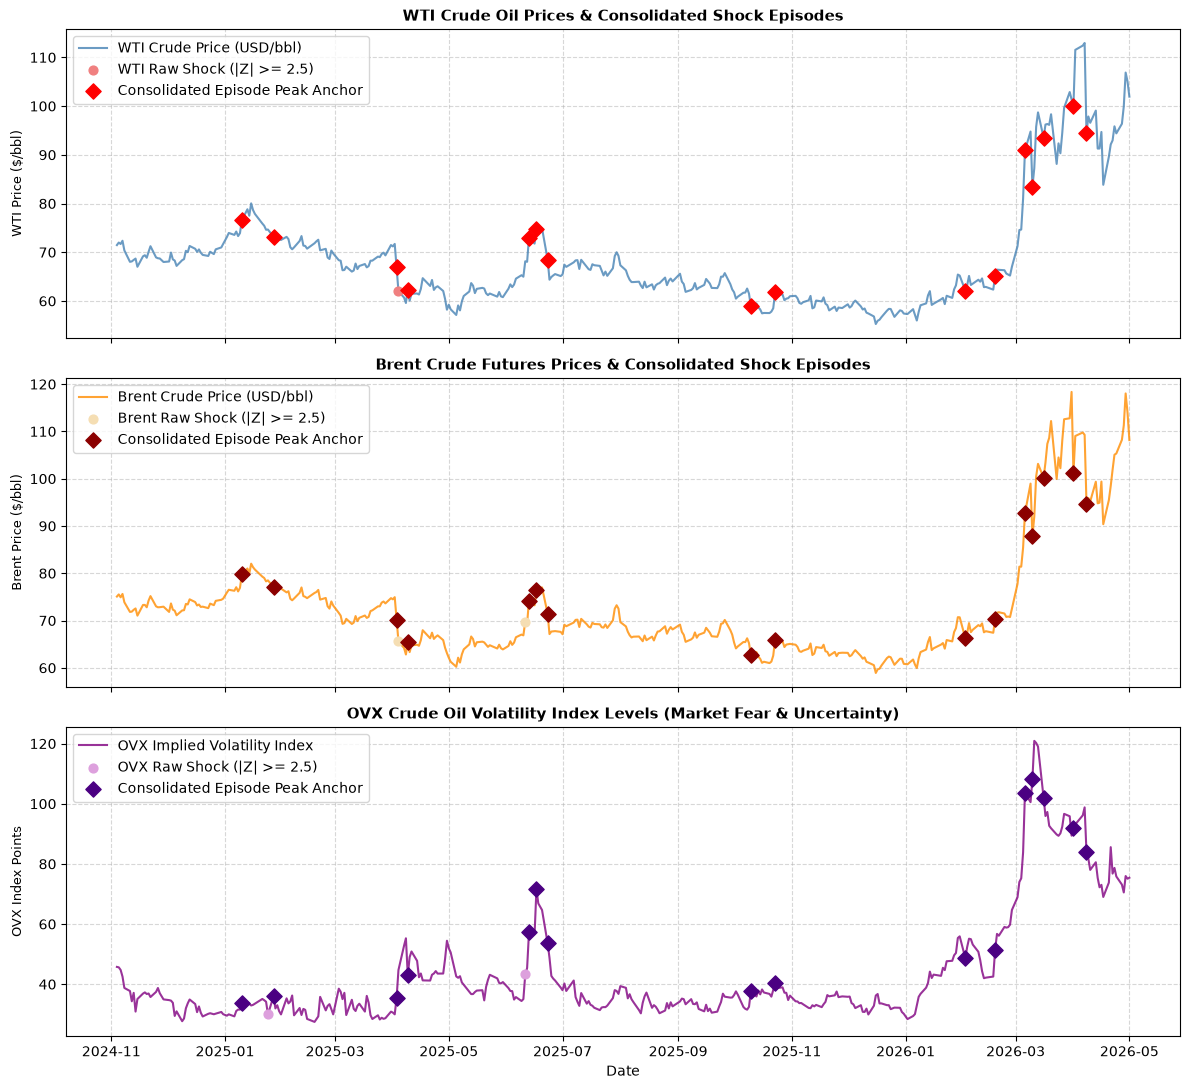

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load WTI, Brent, and OVX data
wti_df = pd.read_csv("../Oil_Markets/WTI.csv")
brent_df = pd.read_csv("../Oil_Markets/Brent.csv")
ovx_df = pd.read_csv("../Oil_Markets/OVX.csv")

# Standardize date format
wti_df["Date"] = pd.to_datetime(wti_df["Date"], format="%d/%m/%Y")
brent_df["Date"] = pd.to_datetime(brent_df["Date"], format="%d/%m/%Y")
ovx_df["Date"] = pd.to_datetime(ovx_df["Date"], format="%d/%m/%Y")

# Sort chronologically (oldest to newest)
wti_df = wti_df.sort_values("Date").reset_index(drop=True)
brent_df = brent_df.sort_values("Date").reset_index(drop=True)
ovx_df = ovx_df.sort_values("Date").reset_index(drop=True)

# Standardize OVX column name if needed
if "PX_LAST" in ovx_df.columns and "PX_LAST_OVX" not in ovx_df.columns:
    ovx_df = ovx_df.rename(columns={"PX_LAST": "PX_LAST_OVX"})

# Merge datasets on Date
market_df = pd.merge(wti_df, brent_df, on="Date", suffixes=("_WTI", "_Brent"))
market_df = pd.merge(market_df, ovx_df, on="Date", how="left")

# Forward-fill any missing OVX values due to holiday/reporting gaps
market_df["PX_LAST_OVX"] = market_df["PX_LAST_OVX"].ffill()
market_df["PX_LAST_WTI"] = market_df["PX_LAST_WTI"].ffill()
market_df["PX_LAST_Brent"] = market_df["PX_LAST_Brent"].ffill()

# 2. Compute Daily Returns & Changes (needed for Z-scores and shock filtering)
market_df["WTI_Return"] = np.log(
    market_df["PX_LAST_WTI"] / market_df["PX_LAST_WTI"].shift(1)
)
market_df["Brent_Return"] = np.log(
    market_df["PX_LAST_Brent"] / market_df["PX_LAST_Brent"].shift(1)
)
market_df["OVX_Change"] = market_df["PX_LAST_OVX"].diff()

# 3. Compute Rolling Volatility (21-day window) and Z-Scores
window = 21

# WTI metrics
market_df["WTI_Rolling_Vol"] = market_df["WTI_Return"].rolling(window).std()
market_df["WTI_Mean_Return"] = market_df["WTI_Return"].rolling(window).mean()
market_df["WTI_ZScore"] = (
    market_df["WTI_Return"] - market_df["WTI_Mean_Return"]
) / market_df["WTI_Rolling_Vol"]

# Brent metrics
market_df["Brent_Rolling_Vol"] = (
    market_df["Brent_Return"].rolling(window).std()
)
market_df["Brent_Mean_Return"] = (
    market_df["Brent_Return"].rolling(window).mean()
)
market_df["Brent_ZScore"] = (
    market_df["Brent_Return"] - market_df["Brent_Mean_Return"]
) / market_df["Brent_Rolling_Vol"]

# OVX metrics
market_df["OVX_Rolling_Vol"] = market_df["OVX_Change"].rolling(window).std()
market_df["OVX_Mean_Change"] = market_df["OVX_Change"].rolling(window).mean()
market_df["OVX_ZScore"] = (
    market_df["OVX_Change"] - market_df["OVX_Mean_Change"]
) / market_df["OVX_Rolling_Vol"]

# 4. Filter for Shocks independently
threshold_z = 2.5
wti_raw_shocks = market_df[market_df["WTI_ZScore"].abs() >= threshold_z].copy()
brent_raw_shocks = market_df[
    market_df["Brent_ZScore"].abs() >= threshold_z
].copy()
ovx_raw_shocks = market_df[market_df["OVX_ZScore"].abs() >= threshold_z].copy()

all_shock_dates = np.union1d(
    wti_raw_shocks["Date"].values,
    np.union1d(brent_raw_shocks["Date"].values, ovx_raw_shocks["Date"].values),
)
raw_events_df = market_df[market_df["Date"].isin(all_shock_dates)].copy()
raw_events_df = raw_events_df.sort_values("Date").reset_index(drop=True)

# 5. Merge Close Dates into Episodes
max_gap_days = 3

def merge_close_dates(events_df, max_gap_days=3):
    if events_df.empty:
        return events_df
        
    events_df = events_df.sort_values('Date').reset_index(drop=True)
    episodes = []
    current_episode = [events_df.loc[0]]
    
    for i in range(1, len(events_df)):
        prev_date = current_episode[-1]['Date']
        curr_date = events_df.loc[i, 'Date']
        
        if (curr_date - prev_date).days <= max_gap_days:
            current_episode.append(events_df.loc[i])
        else:
            episodes.append(current_episode)
            current_episode = [events_df.loc[i]]
    episodes.append(current_episode)
    
    merged_rows = []
    for ep in episodes:
        ep_df = pd.DataFrame(ep)
        ep_df['Z_Magnitude'] = (
            ep_df['WTI_ZScore'].abs().fillna(0) + 
            ep_df['Brent_ZScore'].abs().fillna(0) + 
            ep_df['OVX_ZScore'].abs().fillna(0)
        )
        peak_idx = ep_df['Z_Magnitude'].idxmax()
        peak_row = ep_df.loc[peak_idx].copy()
        
        peak_row['Episode_Start'] = ep_df['Date'].min().strftime('%Y-%m-%d')
        peak_row['Episode_End'] = ep_df['Date'].max().strftime('%Y-%m-%d')
        peak_row['Episode_Count'] = len(ep_df)
        merged_rows.append(peak_row)
        
    return pd.DataFrame(merged_rows).drop(columns=['Z_Magnitude'])

consolidated_events_df = merge_close_dates(raw_events_df, max_gap_days=max_gap_days)

# 6. Plotting 3-Panel Price Level Figure with Event Markers
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 11), sharex=True)

# WTI Price Plot
axes[0].plot(
    market_df["Date"],
    market_df["PX_LAST_WTI"],
    label="WTI Crude Price (USD/bbl)",
    color="steelblue",
    alpha=0.8,
)
axes[0].scatter(
    wti_raw_shocks["Date"],
    wti_raw_shocks["PX_LAST_WTI"],
    color="lightcoral",
    s=40,
    label=f"WTI Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[0].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "PX_LAST_WTI"],
    color="red",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[0].set_title(
    "WTI Crude Oil Prices & Consolidated Shock Episodes",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_ylabel("WTI Price ($/bbl)", fontsize=9)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Brent Price Plot
axes[1].plot(
    market_df["Date"],
    market_df["PX_LAST_Brent"],
    label="Brent Crude Price (USD/bbl)",
    color="darkorange",
    alpha=0.8,
)
axes[1].scatter(
    brent_raw_shocks["Date"],
    brent_raw_shocks["PX_LAST_Brent"],
    color="wheat",
    s=40,
    label=f"Brent Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[1].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "PX_LAST_Brent"],
    color="darkred",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[1].set_title(
    "Brent Crude Futures Prices & Consolidated Shock Episodes",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_ylabel("Brent Price ($/bbl)", fontsize=9)
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)

# OVX Index Plot
axes[2].plot(
    market_df["Date"],
    market_df["PX_LAST_OVX"],
    label="OVX Implied Volatility Index",
    color="purple",
    alpha=0.8,
)
axes[2].scatter(
    ovx_raw_shocks["Date"],
    ovx_raw_shocks["PX_LAST_OVX"],
    color="plum",
    s=40,
    label=f"OVX Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[2].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "PX_LAST_OVX"],
    color="indigo",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[2].set_title(
    "OVX Crude Oil Volatility Index Levels (Market Fear & Uncertainty)",
    fontsize=11,
    fontweight="bold",
)
axes[2].set_xlabel("Date", fontsize=10)
axes[2].set_ylabel("OVX Index Points", fontsize=9)
axes[2].legend(loc="upper left")
axes[2].grid(True, linestyle="--", alpha=0.5)

os.makedirs("Figures", exist_ok=True)
plt.tight_layout()
plt.savefig("Figures/wti_brent_ovx_price_levels_plot.pdf", dpi=300)
plt.show()

Total raw shock dates: 22
Consolidated independent market shock episodes: 18
Successfully exported consolidated shock events to 'wti_brent_events.csv'


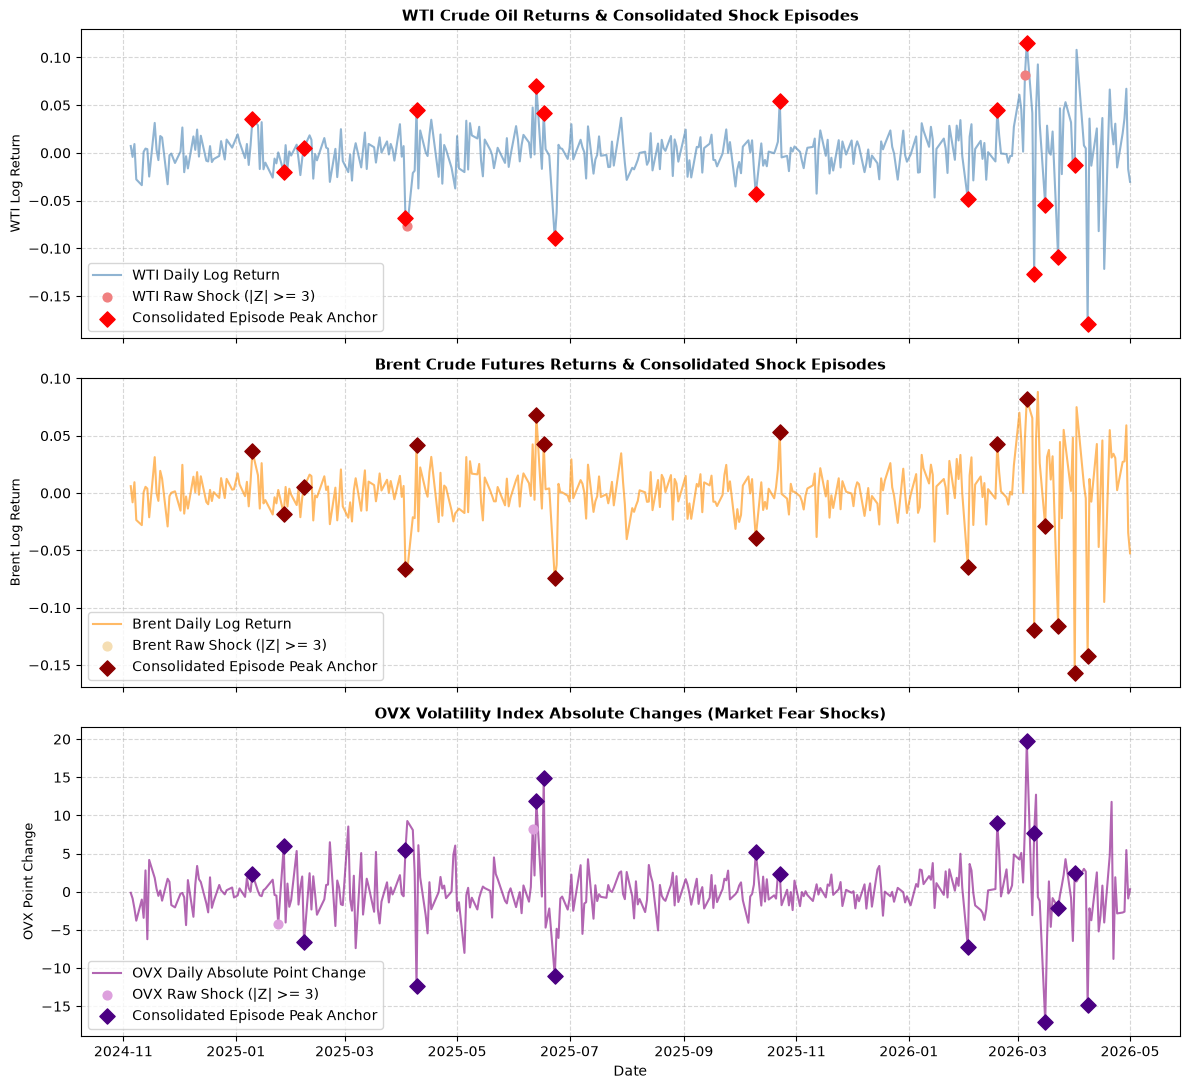

In [17]:
# 1. Load WTI, Brent, and OVX data
wti_df = pd.read_csv("../Oil_Markets/WTI.csv")
brent_df = pd.read_csv("../Oil_Markets/Brent.csv")
ovx_df = pd.read_csv("../Oil_Markets/OVX.csv")

# Standardize date format
wti_df["Date"] = pd.to_datetime(wti_df["Date"], format="%d/%m/%Y")
brent_df["Date"] = pd.to_datetime(brent_df["Date"], format="%d/%m/%Y")
ovx_df["Date"] = pd.to_datetime(ovx_df["Date"], format="%d/%m/%Y")

# CRITICAL FIX: Sort all files chronologically (oldest to newest)
wti_df = wti_df.sort_values("Date").reset_index(drop=True)
brent_df = brent_df.sort_values("Date").reset_index(drop=True)
ovx_df = ovx_df.sort_values("Date").reset_index(drop=True)

# Standardize OVX column name if needed
if "PX_LAST" in ovx_df.columns and "PX_LAST_OVX" not in ovx_df.columns:
    ovx_df = ovx_df.rename(columns={"PX_LAST": "PX_LAST_OVX"})

# Merge datasets on Date
market_df = pd.merge(wti_df, brent_df, on="Date", suffixes=("_WTI", "_Brent"))
market_df = pd.merge(market_df, ovx_df, on="Date", how="left")

# Forward-fill any missing OVX values due to holiday/reporting gaps
# Forward-fill any missing OVX values due to holiday/reporting gaps
market_df["PX_LAST_OVX"] = market_df["PX_LAST_OVX"].ffill()
market_df["PX_LAST_WTI"] = market_df["PX_LAST_WTI"].ffill()
market_df["PX_LAST_Brent"] = market_df["PX_LAST_Brent"].ffill()

# 2. Compute Daily Log Returns for WTI/Brent, and Absolute Point Changes for OVX
market_df["WTI_Return"] = np.log(
    market_df["PX_LAST_WTI"] / market_df["PX_LAST_WTI"].shift(1)
)
market_df["Brent_Return"] = np.log(
    market_df["PX_LAST_Brent"] / market_df["PX_LAST_Brent"].shift(1)
)
market_df["OVX_Change"] = market_df["PX_LAST_OVX"].diff()

# 3. Compute Rolling Volatility (21-day window) and Z-Scores
window = 30

# WTI metrics
market_df["WTI_Rolling_Vol"] = market_df["WTI_Return"].rolling(window).std().shift(1)
market_df["WTI_Mean_Return"] = market_df["WTI_Return"].rolling(window).mean().shift(1)
market_df["WTI_ZScore"] = (market_df["WTI_Return"] - market_df["WTI_Mean_Return"]) / market_df["WTI_Rolling_Vol"]

# Brent metrics
market_df["Brent_Rolling_Vol"] = market_df["Brent_Return"].rolling(window).std().shift(1)
market_df["Brent_Mean_Return"] = market_df["Brent_Return"].rolling(window).mean().shift(1)
market_df["Brent_ZScore"] = (market_df["Brent_Return"] - market_df["Brent_Mean_Return"]) / market_df["Brent_Rolling_Vol"]

# OVX metrics (Using absolute point changes)
market_df["OVX_Rolling_Vol"] = market_df["OVX_Change"].rolling(window).std().shift(1)
market_df["OVX_Mean_Change"] = market_df["OVX_Change"].rolling(window).mean().shift(1)
market_df["OVX_ZScore"] = (market_df["OVX_Change"] - market_df["OVX_Mean_Change"]) / market_df["OVX_Rolling_Vol"]

# 4. Filter for Shocks independently
threshold_z = 3
wti_raw_shocks = market_df[market_df["WTI_ZScore"].abs() >= threshold_z].copy()
brent_raw_shocks = market_df[
    market_df["Brent_ZScore"].abs() >= threshold_z
].copy()
ovx_raw_shocks = market_df[market_df["OVX_ZScore"].abs() >= threshold_z].copy()

# Combine unique union of dates across all three indices
all_shock_dates = np.union1d(
    wti_raw_shocks["Date"].values,
    np.union1d(brent_raw_shocks["Date"].values, ovx_raw_shocks["Date"].values),
)
raw_events_df = market_df[market_df["Date"].isin(all_shock_dates)].copy()
raw_events_df = raw_events_df.sort_values("Date").reset_index(drop=True)

# -------------------------------------------------------------------------
# 5. MERGE CLOSE/CONSECUTIVE SHOCK DATES INTO EPISODES
# -------------------------------------------------------------------------
max_gap_days = 3  # Shocks within 3 days are grouped into a single episode

def merge_close_dates(events_df, max_gap_days=3):
    if events_df.empty:
        return events_df
        
    events_df = events_df.sort_values('Date').reset_index(drop=True)
    episodes = []
    current_episode = [events_df.loc[0]]
    
    for i in range(1, len(events_df)):
        prev_date = current_episode[-1]['Date']
        curr_date = events_df.loc[i, 'Date']
        
        if (curr_date - prev_date).days <= max_gap_days:
            current_episode.append(events_df.loc[i])
        else:
            episodes.append(current_episode)
            current_episode = [events_df.loc[i]]
    episodes.append(current_episode)
    
    merged_rows = []
    for ep in episodes:
        ep_df = pd.DataFrame(ep)
        
        # Use fillna(0) to safely prevent NaN values from crashing idxmax()
        ep_df['Z_Magnitude'] = (
            ep_df['WTI_ZScore'].abs().fillna(0) + 
            ep_df['Brent_ZScore'].abs().fillna(0) + 
            ep_df['OVX_ZScore'].abs().fillna(0)
        )
        
        peak_idx = ep_df['Z_Magnitude'].idxmax()
        peak_row = ep_df.loc[peak_idx].copy()
        
        peak_row['Episode_Start'] = ep_df['Date'].min().strftime('%Y-%m-%d')
        peak_row['Episode_End'] = ep_df['Date'].max().strftime('%Y-%m-%d')
        peak_row['Episode_Count'] = len(ep_df)
        merged_rows.append(peak_row)
        
    return pd.DataFrame(merged_rows).drop(columns=['Z_Magnitude'])

consolidated_events_df = merge_close_dates(raw_events_df, max_gap_days=max_gap_days)

print(f"Total raw shock dates: {len(raw_events_df)}")
print(f"Consolidated independent market shock episodes: {len(consolidated_events_df)}")

# 6. Export consolidated event summary table
output_event_file = "wti_brent_events.csv"
consolidated_events_df.to_csv(output_event_file, index=False)
print(f"Successfully exported consolidated shock events to '{output_event_file}'")

# 7. Plotting 3-Panel Figure (WTI, Brent, and OVX Absolute Change)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 11), sharex=True)

# WTI Plot
axes[0].plot(
    market_df["Date"],
    market_df["WTI_Return"],
    label="WTI Daily Log Return",
    color="steelblue",
    alpha=0.6,
)
axes[0].scatter(
    wti_raw_shocks["Date"],
    wti_raw_shocks["WTI_Return"],
    color="lightcoral",
    s=40,
    label=f"WTI Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[0].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "WTI_Return"],
    color="red",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[0].set_title(
    "WTI Crude Oil Returns & Consolidated Shock Episodes",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_ylabel("WTI Log Return", fontsize=9)
axes[0].legend(loc="lower left")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Brent Plot
axes[1].plot(
    market_df["Date"],
    market_df["Brent_Return"],
    label="Brent Daily Log Return",
    color="darkorange",
    alpha=0.6,
)
axes[1].scatter(
    brent_raw_shocks["Date"],
    brent_raw_shocks["Brent_Return"],
    color="wheat",
    s=40,
    label=f"Brent Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[1].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "Brent_Return"],
    color="darkred",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[1].set_title(
    "Brent Crude Futures Returns & Consolidated Shock Episodes",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_ylabel("Brent Log Return", fontsize=9)
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle="--", alpha=0.5)

# OVX Plot (Absolute Point Change)
axes[2].plot(
    market_df["Date"],
    market_df["OVX_Change"],
    label="OVX Daily Absolute Point Change",
    color="purple",
    alpha=0.6,
)
axes[2].scatter(
    ovx_raw_shocks["Date"],
    ovx_raw_shocks["OVX_Change"],
    color="plum",
    s=40,
    label=f"OVX Raw Shock (|Z| >= {threshold_z})",
    zorder=4,
)
axes[2].scatter(
    consolidated_events_df["Date"],
    market_df.set_index("Date").loc[consolidated_events_df["Date"], "OVX_Change"],
    color="indigo",
    s=60,
    marker="D",
    label="Consolidated Episode Peak Anchor",
    zorder=5,
)
axes[2].set_title(
    "OVX Volatility Index Absolute Changes (Market Fear Shocks)",
    fontsize=11,
    fontweight="bold",
)
axes[2].set_xlabel("Date", fontsize=10)
axes[2].set_ylabel("OVX Point Change", fontsize=9)
axes[2].legend(loc="lower left")
axes[2].grid(True, linestyle="--", alpha=0.5)

os.makedirs("Figures", exist_ok=True)
plt.tight_layout()
plt.savefig("Figures/wti_brent_ovx_market_shocks_plot.pdf", dpi=300)
plt.show()

### LLM Reason for Event

10/01/2025 - "On January 10, 2025, the primary catalyst that drove a sharp and drastic move in the oil markets was a major new package of U.S. sanctions targeting Russia's energy sector and shadow fleet."

27/01/2025 - "This sharp downward correction was driven by a confluence of macroeconomic, trade policy, and broader market events: [Escalating Trade Policy & Tariff Concerns, Broader Financial Markets Rout & Tech Shock, Weakening Economic Indicators from China, Algorithmic and Quant Selling]"

03/04/2025 - "oil markets experienced a major downward jolt and heavy sell-off (with WTI crude dropping significantly—falling by over 4% to under $67 a barrel) driven by a combination of aggressive trade policy shifts and unexpected supply developments: [Escalating U.S. Trade Tariffs, OPEC+ Output Expansion Pressures, Unexpected Inventories Surge]"

09/04/2025 - "oil markets experienced sharp volatility and diverging benchmark movements amidst a chaotic macro environment dominated by trade policy shocks: [U.S. Tariff Shockwaves and Partial Pause, Divergent Crude Benchmark Moves, Recession and Demand Fears]"

13/06/2025 - "oil markets experienced a massive, violent surge (with crude benchmarks jumping roughly 7% to over 13% at their intraday peaks—marking some of the largest daily gains since 2020) driven by a severe military escalation in the Middle East: [Israeli Airstrikes on Iran, Supply Disruption and Strait of Hormuz Fears, Spillover Across Global Markets]"

17/06/2025 - "oil markets experienced a sharp upward jolt (with U.S. WTI crude jumping over 4% to roughly $74.84 a barrel and Brent crude rising more than 4% to near $76.45) driven by escalating geopolitical tensions and high-level political rhetoric: [Escalation in US Rhetoric on Iran, Fears over Middle East Supply and the Strait of Hormuz, Spillover to Broader Financial Markets]"

23/06/2025 - "oil markets experienced a major turning point driven by critical developments in the Twelve-Day War between Israel and Iran: [An Iranian Military Response & Ceasefire Breakthrough, De-escalation of Supply Disruption Fears, Market Stabilization and Subsiding Risk Premium]"

10/10/2025 - "oil markets suffered a sharp sell-off, with West Texas Intermediate (WTI) crude tumbling over 4% to fall below $59 a barrel (reaching its lowest level since May) and Brent crude dropping toward $62–$63 a barrel. This dramatic downward market move was driven by a combination of geopolitical de-escalation, aggressive trade policy threats, and underlying oversupply fears: [The Gaza Ceasefire and Fading Risk Premium, U.S.–China Tariff Threats & Demand Fears, Imminent Global Over-supply Concerns]"

23/10/2025 - "oil markets experienced a notable upward move (with crude prices rising roughly 2% for their second consecutive session, pushing WTI toward $58.50 and Brent past $62.50–$65.60 per barrel depending on the benchmark feed) driven primarily by major geopolitical and trade developments: [U.S.–India Trade Agreement & Russian Oil Restrictions, Ongoing Western Pressure on Russian Energy Exports, U.S.–China Trade Talks Optimism]"

02/02/2026 - "oil markets experienced a sharp, synchronized downward correction and a significant sell-off (with Brent crude dropping roughly 5.2% to $65.69 and WTI falling about 5.5% to $61.61 per barrel). This sharp price movement was driven by a combination of de-escalation and macro-financial forces: [U.S.–Iran Diplomatic De-escalation, Surge in the U.S. Dollar, Contagion and Institutional Portfolio Rebalancing]"

18/02/2026 - "oil markets experienced a notable upward move (with WTI crude rallying about 2.8% to close around $65.19 a barrel), driven largely by the following factors: [Pre-Crisis Geopolitical Accumulation, Technical and Inventory Rebounding]"

06/03/2026 - "oil markets experienced a significant intraday pullback and technical correction, coming right on the heels of a massive, multi-day geopolitical surge: [Hopes for U.S. Market Intervention & Waivers, Cooling After an Initial War-Driven Spike, Technical Profit-Taking]"

10/03/2026 - "oil markets experienced a sharp and massive correction (plummeting over 7% to 8%) after reaching extreme highs just days prior: [Retreat from Near-$120 Peaks, Political Signals of De-escalation, Massive Profit-Taking and Volatility]"

16/03/2026 - "oil markets experienced major headlines and intervention moves driven by the ongoing Middle East conflict and the severe restriction of oil flows through the Strait of Hormuz. The key events that moved the markets on this day include: [The IEA's Historic Emergency Stockpile Release, Strait of Hormuz Security & Trump's Call for Allies, Sustained High Pricing & Volatility]"

01/04/2026 - "oil markets experienced a day of high volatility, fluctuating movements, and high-stakes market re-assessments driven by ongoing Middle East conflicts and political signaling: [Weighing Potential Conflict Resolution & Trump's Rhetoric, Persistent Supply Bottlenecks and Infrastructure Risks, Record Monthly Gains Context]"

08/04/2026 - "oil markets experienced a historic and massive sell-off, plunging roughly 15% to 18% in one of the steepest single-day declines in years. Both Brent crude and WTI crude crashed sharply, falling from near or above $110–$119 back down below the psychological $100-per-barrel threshold (settling toward the low-$90s). This dramatic market move was driven by a major geopolitical de-escalation: [U.S.–Iran Ceasefire Announcement, Relief Rally and Removal of the War Risk Premium, Spillover to Broader Financial Markets]"

# TODO: Must review the above using Factivia 

## Linking clusters to events

In [90]:
# 1. Load datasets
posts_df = pd.read_json("clustered_oil_posts.json")
events_df = pd.read_csv("wti_brent_events.csv")

# 2. Load full price history & OVX index data for window-specific calculations
wti_df = pd.read_csv("Oil_Markets/WTI.csv")
brent_df = pd.read_csv("Oil_Markets/Brent.csv")
ovx_df = pd.read_csv("Oil_Markets/OVX.csv")

# Standardize date formats
wti_df["Date"] = pd.to_datetime(wti_df["Date"], format="%d/%m/%Y")
brent_df["Date"] = pd.to_datetime(brent_df["Date"], format="%d/%m/%Y")
ovx_df["Date"] = pd.to_datetime(ovx_df["Date"], format="%d/%m/%Y")

# CRITICAL FIX: Sort chronologically (oldest to newest)
wti_df = wti_df.sort_values("Date").reset_index(drop=True)
brent_df = brent_df.sort_values("Date").reset_index(drop=True)
ovx_df = ovx_df.sort_values("Date").reset_index(drop=True)

# Standardize OVX column name if needed
if "PX_LAST" in ovx_df.columns and "PX_LAST_OVX" not in ovx_df.columns:
    ovx_df = ovx_df.rename(columns={"PX_LAST": "PX_LAST_OVX"})

# Merge market panels on Date
market_full = pd.merge(wti_df, brent_df, on="Date", suffixes=("_WTI", "_Brent"))
market_full = pd.merge(market_full, ovx_df, on="Date", how="left")

# Forward-fill any minor reporting/holiday gaps in OVX data
market_full["PX_LAST_OVX"] = market_full["PX_LAST_OVX"].ffill()

# Compute daily log returns for WTI/Brent, and absolute point changes for OVX
market_full["WTI_Return"] = np.log(
    market_full["PX_LAST_WTI"] / market_full["PX_LAST_WTI"].shift(1)
)
market_full["Brent_Return"] = np.log(
    market_full["PX_LAST_Brent"] / market_full["PX_LAST_Brent"].shift(1)
)
market_full["OVX_Change"] = market_full["PX_LAST_OVX"].diff()

# 3. Define Cluster Name Mapping Dictionary
cluster_name_mapping = {
    0: "Geopolitical Confrontation & Naval Security Enforcement",
    1: "Domestic Partisan Blame & Institutional Critique",
    2: "International Diplomacy & Peace-Through-Strength Accords",
    3: "Administration Appointments & Foreign Policy Personnel",
    4: "America First Legislative & Campaign Endorsements",
    5: "Energy Dominance & Domestic Production Expansion",
    6: "Macroeconomic Policy & Inflationary Critique",
}

# 4. Standardize dates
posts_df["post_date"] = pd.to_datetime(
    posts_df["post_metadata"].apply(
        lambda x: x.get("created_utc") if isinstance(x, dict) else None
    )
).dt.tz_localize(None)

events_df["event_date"] = pd.to_datetime(events_df["Date"])

# Identify rubric keys dynamically
sample_scores = posts_df["scores"].dropna().iloc[0]
rubric_keys = list(sample_scores.keys()) if isinstance(sample_scores, dict) else []

# 5. Define Window Timeframes
windows = [
    ("Trading Window [-1, +1]", 1, 1, False),
    ("Trading Window [-3, +3]", 3, 3, False),
    ("Calendar Window [10 Days]", 5, 5, True),
    ("Calendar Policy Window [30 Days]", 15, 15, True),
]

split_window_summary = []

print(
    "=== CALCULATING WINDOW METRICS (WTI, BRENT, OVX) & SPLITTING ROWS ==="
)

for _, event in events_df.iterrows():
    e_date = event["event_date"]
    wti_z = event["WTI_ZScore"]
    brent_z = event["Brent_ZScore"]
    ovx_z = (
        event["OVX_ZScore"] if "OVX_ZScore" in event and pd.notna(event["OVX_ZScore"]) else 0.0
    )

    for w_name, b_val, a_val, is_calendar in windows:
        if is_calendar:
            start_w = e_date - timedelta(days=b_val)
            end_w = e_date + timedelta(days=a_val)
        else:
            start_w = e_date - timedelta(days=int(b_val * 1.4))
            end_w = e_date + timedelta(days=int(a_val * 1.4))

        # A. Calculate Window Market Metrics from market_full panel
        sub_market = market_full[
            (market_full["Date"] >= start_w) & (market_full["Date"] <= end_w)
        ]

        if len(sub_market) >= 2:
            # WTI & Brent Cumulative Return over the window as percentage: ln(Price_end / Price_start) * 100
            wti_start = sub_market["PX_LAST_WTI"].iloc[0]
            wti_end = sub_market["PX_LAST_WTI"].iloc[-1]
            window_wti_return = np.log(wti_end / wti_start) * 100

            brent_start = sub_market["PX_LAST_Brent"].iloc[0]
            brent_end = sub_market["PX_LAST_Brent"].iloc[-1]
            window_brent_return = np.log(brent_end / brent_start) * 100

            # Realized Volatility within the window as percentage: std * 100
            window_wti_vol = sub_market["WTI_Return"].std() * 100
            window_brent_vol = sub_market["Brent_Return"].std() * 100

            # OVX Window Metrics: Absolute cumulative point change & realized volatility of absolute point changes
            ovx_start = sub_market["PX_LAST_OVX"].iloc[0]
            ovx_end = sub_market["PX_LAST_OVX"].iloc[-1]
            window_ovx_change = ovx_end - ovx_start
            window_ovx_vol = sub_market["OVX_Change"].std()
        else:
            window_wti_return, window_brent_return, window_wti_vol, window_brent_vol = (
                0.0,
                0.0,
                0.0,
                0.0,
            )
            window_ovx_change, window_ovx_vol = 0.0, 0.0

        # B. Filter posts inside the full window
        full_window_posts = posts_df[
            (posts_df["post_date"] >= start_w)
            & (posts_df["post_date"] <= end_w + timedelta(hours=23, minutes=59))
        ].copy()

        # Split into Before and After phases relative to the event date
        before_posts = full_window_posts[
            full_window_posts["post_date"] < e_date.normalize()
        ]
        after_posts = full_window_posts[
            full_window_posts["post_date"] >= e_date.normalize()
        ]

        def aggregate_phase_row(subset, phase_name):
            n_posts = len(subset)
            if n_posts > 0:
                raw_counts = subset["cluster_id"].value_counts().to_dict()
                cluster_counts = {
                    cluster_name_mapping.get(k, f"Cluster {k}"): v
                    for k, v in raw_counts.items()
                }
                dom_id = subset["cluster_id"].mode()[0]
                dominant_cluster_name = cluster_name_mapping.get(
                    dom_id, f"Cluster {dom_id}"
                )
            else:
                cluster_counts = {}
                dominant_cluster_name = "None (No Posts)"

            avg_scores = {}
            for r_key in rubric_keys:
                vals = (
                    subset["scores"].apply(
                        lambda x: x.get(r_key, 0) if isinstance(x, dict) else 0
                    )
                    if n_posts > 0
                    else pd.Series([0])
                )
                avg_scores[f"avg_{r_key}"] = vals.mean()

            row = {
                "event_date": e_date.strftime("%Y-%m-%d"),
                "window_type": w_name,
                "phase": phase_name,  # 'Before Event' or 'After Event'
                "total_relevant_posts": n_posts,
                "dominant_cluster": dominant_cluster_name,
                "window_wti_cumulative_return_pct": round(window_wti_return, 2),
                "window_brent_cumulative_return_pct": round(window_brent_return, 2),
                "window_wti_realized_volatility_pct": round(window_wti_vol, 2),
                "window_brent_realized_volatility_pct": round(window_brent_vol, 2),
                "window_ovx_cumulative_change": round(window_ovx_change, 2),
                "window_ovx_realized_volatility": round(window_ovx_vol, 2),
                "wti_shock_zscore": wti_z,
                "brent_shock_zscore": brent_z,
                "ovx_shock_zscore": ovx_z,
                "cluster_distribution": str(cluster_counts),
            }
            row.update(avg_scores)
            return row

        # Append rows for both phases
        split_window_summary.append(
            aggregate_phase_row(before_posts, "Before Event")
        )
        split_window_summary.append(
            aggregate_phase_row(after_posts, "After Event")
        )

# 6. Export table
summary_df = pd.DataFrame(split_window_summary)
output_filename = "cluster_events.csv"
summary_df.to_csv(output_filename, index=False)

print(
    f"\nSuccessfully generated table with WTI, Brent, OVX percentages and row-splits! Saved to '{output_filename}'"
)
print(
    summary_df[
        [
            "event_date",
            "window_type",
            "phase",
            "total_relevant_posts",
            "window_wti_cumulative_return_pct",
            "window_ovx_cumulative_change",
            "ovx_shock_zscore",
        ]
    ].head(6)
)

=== CALCULATING WINDOW METRICS (WTI, BRENT, OVX) & SPLITTING ROWS ===

Successfully generated table with WTI, Brent, OVX percentages and row-splits! Saved to 'cluster_events.csv'
   event_date                window_type         phase  total_relevant_posts  \
0  2025-01-10    Trading Window [-1, +1]  Before Event                     2   
1  2025-01-10    Trading Window [-1, +1]   After Event                     3   
2  2025-01-10    Trading Window [-3, +3]  Before Event                     4   
3  2025-01-10    Trading Window [-3, +3]   After Event                     4   
4  2025-01-10  Calendar Window [10 Days]  Before Event                     4   
5  2025-01-10  Calendar Window [10 Days]   After Event                     7   

   window_wti_cumulative_return_pct  window_ovx_cumulative_change  \
0                              3.52                          2.35   
1                              3.52                          2.35   
2                              5.22                  

## Financial Tests

In [11]:
# 1. Load your summary dataset
df = pd.read_csv("cluster_events.csv")

print("=== STAGE 6: LIMITED FINANCIAL TESTS ===")

# -------------------------------------------------------------
# TEST 1: Mean Oil Return / Volatility Following High vs. Low Urgency Posts
# -------------------------------------------------------------
print(
    "\n--- TEST 1: High-Urgency vs. Low-Urgency Discourse Impact (After Event Phase) ---"
)

after_df = df[df["phase"] == "After Event"].copy()
urgency_median = after_df["avg_rhetorical_urgency_affect"].median()
after_df["High_Urgency"] = (
    after_df["avg_rhetorical_urgency_affect"] > urgency_median
)

t1_expanded = (
    after_df.groupby("High_Urgency")
    .agg(
        Mean_WTI_Return=("window_wti_cumulative_return_pct", "mean"),
        Mean_Brent_Return=("window_brent_cumulative_return_pct", "mean"),
        Mean_WTI_Vol=("window_wti_realized_volatility_pct", "mean"),
        Mean_Brent_Vol=("window_brent_realized_volatility_pct", "mean"),
        Mean_OVX_Change=("window_ovx_cumulative_change", "mean"),
        Count=("event_date", "count"),
    )
    .reset_index()
)
print(t1_expanded)

# -------------------------------------------------------------
# TEST 2: Oil Volatility Around Geopolitical-Threat Clusters
# -------------------------------------------------------------
print(
    "\n--- TEST 2: Market Volatility Across Geopolitical Threat Intensity ---"
)

# Split geopolitical threat scores into High vs Low
threat_median = df["avg_geopolitical_confrontation_threats"].median()
df["High_Geopolitical_Threat"] = (
    df["avg_geopolitical_confrontation_threats"] > threat_median
)

t2_expanded = (
    df.groupby(["window_type", "High_Geopolitical_Threat"])
    .agg(
        Mean_WTI_Vol=("window_wti_realized_volatility_pct", "mean"),
        Mean_Brent_Vol=("window_brent_realized_volatility_pct", "mean"),
        Mean_OVX_Vol=("window_ovx_realized_volatility", "mean"),
    )
    .reset_index()
)
print(t2_expanded.to_string(index=False))

# -------------------------------------------------------------
# TEST 3: Cluster-Share Changes Before and After Major Events
# -------------------------------------------------------------
print("\n--- TEST 3: Dominant Cluster Proportions (Before vs. After) ---")

# Compare dominant cluster frequency before vs after across windows
cluster_shift = (
    pd.crosstab(
        df["dominant_cluster"], df["phase"], normalize="columns"
    )
    * 100
)
print(cluster_shift.round(2))


=== STAGE 6: LIMITED FINANCIAL TESTS ===

--- TEST 1: High-Urgency vs. Low-Urgency Discourse Impact (After Event Phase) ---
   High_Urgency  Mean_WTI_Return  Mean_Brent_Return  Mean_WTI_Vol  \
0         False           3.3675           3.765625      3.609062   
1          True           3.0000           2.172187      4.456250   

   Mean_Brent_Vol  Mean_OVX_Change  Count  
0        3.270313         5.614687     32  
1        4.516875         5.762812     32  

--- TEST 2: Market Volatility Across Geopolitical Threat Intensity ---
                     window_type  High_Geopolitical_Threat  Mean_WTI_Vol  Mean_Brent_Vol  Mean_OVX_Vol
Calendar Policy Window [30 Days]                     False      2.476111        2.258889      3.338889
Calendar Policy Window [30 Days]                      True      4.982143        4.741429      6.061429
       Calendar Window [10 Days]                     False      2.920000        2.670000      3.792667
       Calendar Window [10 Days]                    

### Test 1 Overview

Lower mean returns and higher realsied volatility in high urgency rhetoric posts for WTI and Brent futures suggesting high urgency posts bring fear to the market in all event windows. Price pressure weakens but volatility increases. 

### Test 2 Overview

During a high political threat post, the realised volatilities of WTI, Brent and OVX increase in all event windows pertaining to short term and lasting structure shifts in volatility.

### Test 3 Overview

"Administration Appointments & Foreign Policy Personnel", "America First Legislative & Campaign Endorsements", "Geopolitical Confrontation & Naval Security Enforcement" act consistent before and after an event.

"Domestic Partisan Blame & Institutional Critique", "Macroeconomic Policy & Inflationary Critique" reduce after the event suggesting that potentially these are Trump affected movements in the market. Endogenous events

"International Diplomacy & Peace-Through-Strength Accords" increase after an event suggesting these are Trump's reaction to non Trump related events. Exogenous events.

In [97]:
import statsmodels.formula.api as smf
import pandas as pd

# Load dataset
df = pd.read_csv("cluster_events.csv")

print("=== RUNNING MULTI-MARKET REGRESSIONS (WTI, BRENT, OVX) ===")

# -------------------------------------------------------------
# 1. TIMING ASYMMETRY REGRESSIONS (Pre vs. Post Posts)
# -------------------------------------------------------------
pivoted_posts = df.pivot_table(
    index=[
        "event_date",
        "window_type",
        "window_wti_realized_volatility_pct",
        "window_brent_realized_volatility_pct",
        "window_ovx_realized_volatility",
    ],
    columns="phase",
    values="total_relevant_posts",
    fill_value=0,
).reset_index()
pivoted_posts.columns.name = None
pivoted_posts = pivoted_posts.rename(
    columns={"Before Event": "Posts_Before", "After Event": "Posts_After"}
)

# Run across WTI, Brent, and OVX realized volatility
m_timing_wti = smf.ols(
    "window_wti_realized_volatility_pct ~ Posts_Before + Posts_After",
    data=pivoted_posts,
).fit()
m_timing_brent = smf.ols(
    "window_brent_realized_volatility_pct ~ Posts_Before + Posts_After",
    data=pivoted_posts,
).fit()
m_timing_ovx = smf.ols(
    "window_ovx_realized_volatility ~ Posts_Before + Posts_After",
    data=pivoted_posts,
).fit()

print("\n--- 1. TIMING ASYMMETRY REGRESSIONS ---")
print("WTI Volatility Model Summary:")
print(m_timing_wti.summary())
print("\nBrent Volatility Model Summary:")
print(m_timing_brent.summary())
print("\nOVX Volatility Model Summary:")
print(m_timing_ovx.summary())

# -------------------------------------------------------------
# 2. THEMATIC GRANULARITY REGRESSIONS (Isolating Topics)
# -------------------------------------------------------------
m_theme_wti = smf.ols(
    "window_wti_realized_volatility_pct ~ avg_geopolitical_confrontation_threats + avg_macro_tariff_dollar_weaponization + avg_domestic_production_expansion",
    data=df,
).fit()
m_theme_brent = smf.ols(
    "window_brent_realized_volatility_pct ~ avg_geopolitical_confrontation_threats + avg_macro_tariff_dollar_weaponization + avg_domestic_production_expansion",
    data=df,
).fit()
m_theme_ovx = smf.ols(
    "window_ovx_realized_volatility ~ avg_geopolitical_confrontation_threats + avg_macro_tariff_dollar_weaponization + avg_domestic_production_expansion",
    data=df,
).fit()

print("\n--- 2. THEMATIC GRANULARITY REGRESSIONS ---")
print("WTI Thematic Model Summary:")
print(m_theme_wti.summary())
print("\nBrent Thematic Model Summary:")
print(m_theme_brent.summary())
print("\nOVX Thematic Model Summary:")
print(m_theme_ovx.summary())

# -------------------------------------------------------------
# 3. URGENCY INTERACTION REGRESSIONS (Threat x Urgency)
# -------------------------------------------------------------
m_inter_wti = smf.ols(
    "window_wti_realized_volatility_pct ~ avg_geopolitical_confrontation_threats * avg_rhetorical_urgency_affect",
    data=df,
).fit()
m_inter_brent = smf.ols(
    "window_brent_realized_volatility_pct ~ avg_geopolitical_confrontation_threats * avg_rhetorical_urgency_affect",
    data=df,
).fit()
m_inter_ovx = smf.ols(
    "window_ovx_realized_volatility ~ avg_geopolitical_confrontation_threats * avg_rhetorical_urgency_affect",
    data=df,
).fit()

print("\n--- 3. URGENCY INTERACTION REGRESSIONS ---")
print("WTI Interaction Model Summary:")
print(m_inter_wti.summary())
print("\nBrent Interaction Model Summary:")
print(m_inter_brent.summary())
print("\nOVX Interaction Model Summary:")
print(m_inter_ovx.summary())

=== RUNNING MULTI-MARKET REGRESSIONS (WTI, BRENT, OVX) ===

--- 1. TIMING ASYMMETRY REGRESSIONS ---
WTI Volatility Model Summary:
                                    OLS Regression Results                                    
Dep. Variable:     window_wti_realized_volatility_pct   R-squared:                       0.054
Model:                                            OLS   Adj. R-squared:                  0.023
Method:                                 Least Squares   F-statistic:                     1.735
Date:                                Fri, 31 Jul 2026   Prob (F-statistic):              0.185
Time:                                        14:46:28   Log-Likelihood:                -141.37
No. Observations:                                  64   AIC:                             288.7
Df Residuals:                                      61   BIC:                             295.2
Df Model:                                           2                                         
Covariance Type

### Test 4 Overview

#### Timing Assymetry

Tests whether vlume of posts before and after an event have any effect on volatility. Helping assess exo/endogenous posts

All 3 tests failed to produce a significant value. WTI produce marginal significant test for posts before and OVX produced significant test for posts after.


#### Thematic 

Tests whether certain topics do move volatiliity of the markets inducing fear factor or clarity of mind into the markets

All 3 tests produced very significant values to prove that themes centered around threats, weaponisation and production are associated with volatility movement of the markets


#### Urgency 

Tests whether the tone and urgency of a post rationalises the realised volatility of the market. 

All 3 produced very significant values. However, combining urgency and threat itself did not produce a significant value which can be seen as counterintuitive potentially making Trump's threats seem empty. However, this could be a side effect of collinearity


# TODO: Test on Returns? Fix potential collinearity issue?

